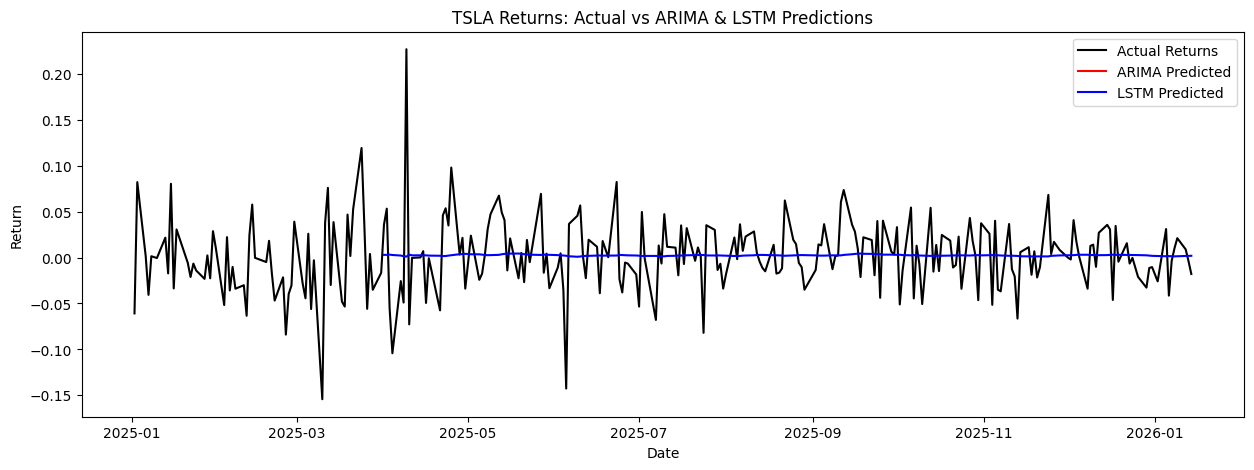

Model Comparison Table:
      ARIMA        LSTM
MAE     NaN    0.026939
RMSE    NaN    0.037444
MAPE    NaN  137.324325


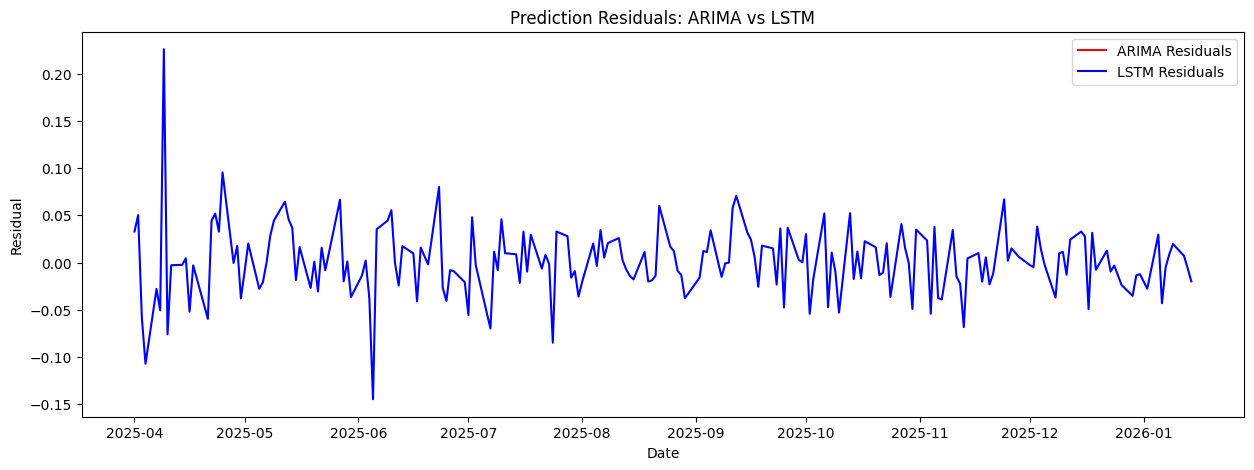

In [30]:
# =======================
# forecast_analysis.ipynb
# =======================

# =======================
# 1. Imports
# =======================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import load_model
import pickle
from pathlib import Path
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")

# Custom modules
from src.tsla_data_load import load_tsla_processed_data, split_train_test_by_date
from src.tsla_data_load_lstm import load_tsla_for_lstm, split_train_test_lstm
from src.tsla_sequence_builder import create_sequences

# =======================
# 2. Paths
# =======================
BASE_DIR = Path.cwd().parent
DATA_PATH = BASE_DIR / "data" / "processed" / "TSLA_cleaned.csv"
MODELS_DIR = BASE_DIR / "models"
ARIMA_MODEL_PATH = MODELS_DIR / "arima_tsla_model.pkl"
LSTM_MODEL_PATH = MODELS_DIR / "lstm_tsla_model.keras"

# =======================
# 3. Load processed TSLA data
# =======================
df = load_tsla_processed_data(DATA_PATH)
df_returns = df["Return"].dropna()  # use returns

# =======================
# 4. Train-Test Split
# =======================
SPLIT_DATE = "2025-01-01"

# --- ARIMA ---
train_arima, test_arima = split_train_test_by_date(
    df=df,
    target_col="Return",
    split_date=SPLIT_DATE
)

# --- LSTM ---
df_lstm, series_scaled, scaler = load_tsla_for_lstm(DATA_PATH, target_col="Return")
train_scaled, test_scaled = split_train_test_lstm(series_scaled, df_lstm, SPLIT_DATE)
SEQ_LEN = 60
X_test, y_test = create_sequences(test_scaled, sequence_length=SEQ_LEN)

# =======================
# 5. Load Models
# =======================
# --- ARIMA ---
with open(ARIMA_MODEL_PATH, "rb") as f:
    arima_model = pickle.load(f)

# --- LSTM ---
lstm_model = load_model(LSTM_MODEL_PATH)

# =======================
# 6. Generate Predictions
# =======================
# --- ARIMA ---
arima_pred_values = arima_model.predict(n_periods=len(test_arima))
arima_pred = pd.Series(arima_pred_values, index=test_arima.index)

# --- LSTM ---
y_pred_scaled = lstm_model.predict(X_test, verbose=0)
y_pred = scaler.inverse_transform(y_pred_scaled.reshape(-1,1)).flatten()
y_true = scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

# Align LSTM index
split_idx = df_lstm.index.searchsorted(pd.to_datetime(SPLIT_DATE))
lstm_index = df_lstm.index[split_idx + SEQ_LEN:]


y_pred = pd.Series(y_pred, index=lstm_index)
y_true = pd.Series(y_true, index=lstm_index)


# =======================
# 7. Plot Actual vs Predicted Returns
# =======================
plt.figure(figsize=(15,5))
plt.plot(test_arima.index, test_arima.values, label="Actual Returns", color='black')
plt.plot(arima_pred.index, arima_pred.values, label="ARIMA Predicted", color='red')
plt.plot(y_true.index, y_pred.values, label="LSTM Predicted", color='blue')
plt.title("TSLA Returns: Actual vs ARIMA & LSTM Predictions")
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend()
plt.show()

# =======================
# 8. Safe Evaluation Function
# =======================
def safe_evaluate(y_true, y_pred):
    # Convert to NumPy arrays
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()

    # Remove NaNs
    valid_idx = ~np.isnan(y_true) & ~np.isnan(y_pred)
    y_true = y_true[valid_idx]
    y_pred = y_pred[valid_idx]

    # If no valid samples, return NaN
    if len(y_true) == 0:
        return np.nan, np.nan, np.nan

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return mae, rmse, mape

# =======================
# 9. Evaluate Metrics
# =======================
arima_mae, arima_rmse, arima_mape = safe_evaluate(test_arima.values, arima_pred.values)
lstm_mae, lstm_rmse, lstm_mape = safe_evaluate(y_true.values, y_pred.values)

# =======================
# 10. Comparison Table
# =======================
comparison_df = pd.DataFrame({
    "ARIMA": [arima_mae, arima_rmse, arima_mape],
    "LSTM": [lstm_mae, lstm_rmse, lstm_mape]
}, index=["MAE", "RMSE", "MAPE"])

print("Model Comparison Table:")
print(comparison_df)

# =======================
# 11. Residuals Plot
# =======================
plt.figure(figsize=(15,5))
plt.plot(test_arima.index, test_arima.values - arima_pred.values, label="ARIMA Residuals", color='red')
plt.plot(y_true.index, y_true.values - y_pred.values, label="LSTM Residuals", color='blue')
plt.title("Prediction Residuals: ARIMA vs LSTM")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.legend()
plt.show()


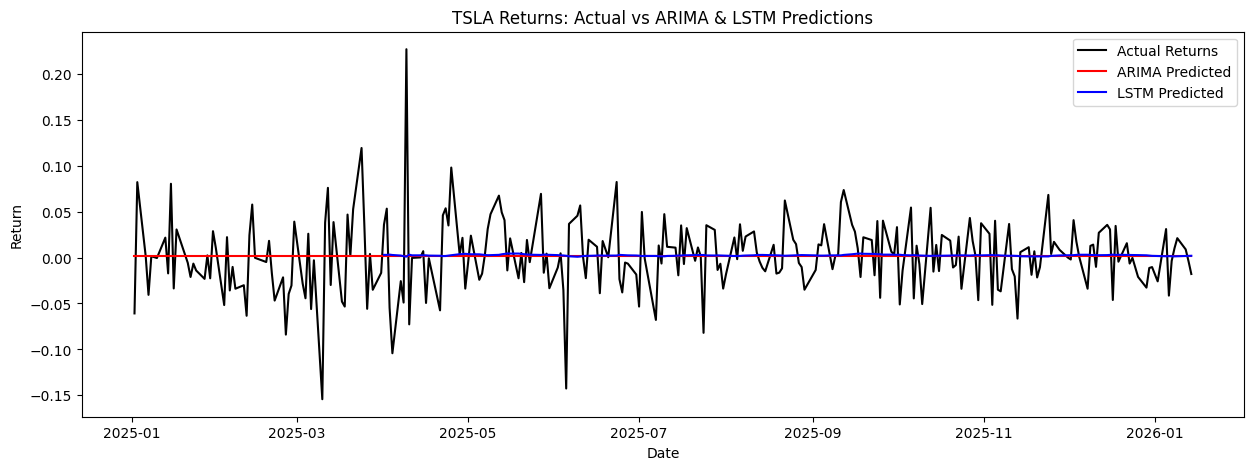

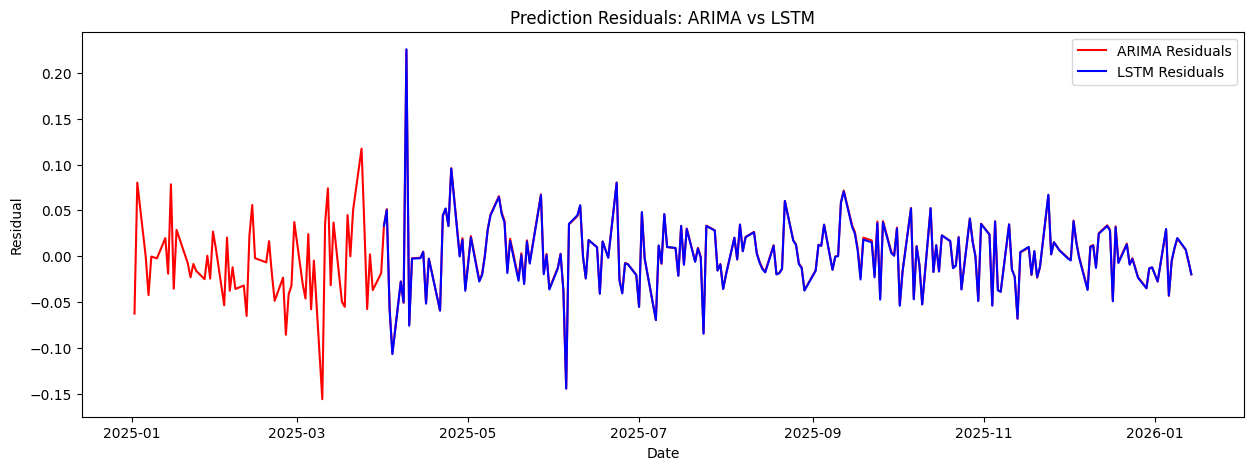

Model Comparison Table:
           ARIMA        LSTM
MAE     0.028875    0.026939
RMSE    0.039440    0.037444
MAPE  125.786238  137.317090


In [6]:
# =======================
# forecast_analysis.ipynb - FULL FIXED VERSION
# =======================

# =======================
# 1. Imports
# =======================
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import load_model
import pickle
from pathlib import Path
import warnings

# Add parent directory to path so 'src' can be imported
BASE_DIR = Path.cwd().parent
sys.path.append(str(BASE_DIR))

# For ARIMA
import pmdarima as pm

# Custom modules
from src.tsla_data_load import load_tsla_processed_data, split_train_test_by_date
from src.tsla_data_load_lstm import load_tsla_for_lstm, split_train_test_lstm
from src.tsla_sequence_builder import create_sequences

warnings.filterwarnings("ignore")

# =======================
# 2. Paths
# =======================
DATA_PATH = BASE_DIR / "data" / "processed" / "TSLA_cleaned.csv"
MODELS_DIR = BASE_DIR / "models"
ARIMA_MODEL_PATH = MODELS_DIR / "arima_tsla_model.pkl"
LSTM_MODEL_PATH = MODELS_DIR / "lstm_tsla_model.keras"

# =======================
# 3. Load processed TSLA data
# =======================
df = load_tsla_processed_data(DATA_PATH)
df_returns = df["Return"].dropna()

# =======================
# 4. Train-Test Split
# =======================
SPLIT_DATE = "2025-01-01"

# --- ARIMA ---
train_arima, test_arima = split_train_test_by_date(
    df=df,
    target_col="Return",
    split_date=SPLIT_DATE
)

# --- LSTM ---
df_lstm, series_scaled, scaler = load_tsla_for_lstm(DATA_PATH, target_col="Return")
train_scaled, test_scaled = split_train_test_lstm(series_scaled, df_lstm, SPLIT_DATE)

SEQ_LEN = 60
X_test, y_test = create_sequences(test_scaled, sequence_length=SEQ_LEN)

# =======================
# 5. Load Models
# =======================
# --- ARIMA ---
with open(ARIMA_MODEL_PATH, "rb") as f:
    arima_model = pickle.load(f)

# --- LSTM ---
lstm_model = load_model(LSTM_MODEL_PATH)

# =======================
# 6. Generate Predictions
# =======================

# --- ARIMA ---
arima_pred_values = arima_model.predict(n_periods=len(test_arima))
arima_pred_values = np.array(arima_pred_values).flatten()

# Align ARIMA predictions with test set
if len(arima_pred_values) > len(test_arima):
    arima_pred_values = arima_pred_values[:len(test_arima)]
elif len(arima_pred_values) < len(test_arima):
    test_arima = test_arima.iloc[:len(arima_pred_values)]

arima_pred = pd.Series(arima_pred_values, index=test_arima.index)

# --- LSTM ---
y_pred_scaled = lstm_model.predict(X_test, verbose=0)
y_pred = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
y_true = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

# =======================
# 6a. Align LSTM predictions to test dates safely
# =======================
seq_len = SEQ_LEN
n_pred = len(y_pred)
if n_pred > 0:
    lstm_index = test_arima.index[seq_len:seq_len + n_pred]
    y_pred = pd.Series(y_pred, index=lstm_index)
    y_true = pd.Series(y_true, index=lstm_index)
else:
    y_pred = pd.Series([], dtype=float)
    y_true = pd.Series([], dtype=float)

# =======================
# 7. Plot Actual vs Predicted Returns
# =======================
plt.figure(figsize=(15,5))
plt.plot(test_arima.index, test_arima.values, label="Actual Returns", color='black')
plt.plot(arima_pred.index, arima_pred.values, label="ARIMA Predicted", color='red')
plt.plot(y_true.index, y_pred.values, label="LSTM Predicted", color='blue')
plt.title("TSLA Returns: Actual vs ARIMA & LSTM Predictions")
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend()
plt.show()

# =======================
# 8. Residuals Plot
# =======================
plt.figure(figsize=(15,5))
plt.plot(test_arima.index, test_arima.values - arima_pred.values, label="ARIMA Residuals", color='red')
plt.plot(y_true.index, y_true.values - y_pred.values, label="LSTM Residuals", color='blue')
plt.title("Prediction Residuals: ARIMA vs LSTM")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.legend()
plt.show()

# =======================
# 9. Evaluate Metrics Safely
# =======================
def safe_evaluate(y_true, y_pred):
    try:
        if len(y_true) == 0 or len(y_pred) == 0:
            raise ValueError("No valid samples available for evaluation.")
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mape = np.mean(np.abs((y_true - y_pred)/(y_true + 1e-8))) * 100
        return mae, rmse, mape
    except Exception as e:
        print(f"[Warning] Evaluation failed: {e}")
        return np.nan, np.nan, np.nan

# Compute metrics
arima_mae, arima_rmse, arima_mape = safe_evaluate(test_arima.values, arima_pred.values)
lstm_mae, lstm_rmse, lstm_mape = safe_evaluate(y_true.values, y_pred.values)

# Comparison table
comparison_df = pd.DataFrame({
    "ARIMA": [arima_mae, arima_rmse, arima_mape],
    "LSTM": [lstm_mae, lstm_rmse, lstm_mape]
}, index=["MAE", "RMSE", "MAPE"])

print("Model Comparison Table:")
print(comparison_df)
